In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

def read_sounding(file):
    with open(file) as f: lines=f.readlines()
    header=lines[1].split()
    return pd.read_csv(file,sep=r"\s*\|\s*",engine="python",skiprows=3,header=None,names=header)

def detect_inversion(df,max_index=300):
    profile=df[["level","745"]].dropna()
    profile=profile[profile["level"]<=max_index]

    if len(profile)<10:
        return np.nan,np.nan

    idx=profile["level"].values
    T=profile["745"].values

    order=np.argsort(idx)
    idx,T=idx[order],T[order]

    dT=np.diff(T)
    peak=np.argmax(dT)

    return dT[peak],idx[peak]


soundings_dir=Path("/users/jdelbeke/soundings")
files=sorted(soundings_dir.glob("*_06610_data.txt"))

cutoff=pd.Timestamp("2025-08-01")

results=[]

for file in files:
    df=read_sounding(file)
    df["termin"]=pd.to_datetime(df["termin"].astype(str))

    df=df[df["termin"]>=cutoff]

    for termin,sounding in df.groupby("termin"):
        strength,index=detect_inversion(sounding)
        results.append({
            "file":file.name,
            "termin":termin,
            "inversion_strength":strength,
            "inversion_index":index
        })

results=pd.DataFrame(results)
results.head()

,file,termin,inversion_strength,inversion_index
0,20250801_06610_data.txt,2025-08-01 00:00:00,0.91,0.0
1,20250801_06610_data.txt,2025-08-01 12:00:00,0.04,243.0
2,20250802_06610_data.txt,2025-08-02 00:00:00,1.48,0.0
3,20250802_06610_data.txt,2025-08-02 12:00:00,0.78,0.0
4,20250803_06610_data.txt,2025-08-03 00:00:00,0.42,0.0


In [7]:
inv=results.dropna(subset=["inversion_strength"]).copy()
inv=inv[inv["inversion_strength"]>0]

strongest25=inv.sort_values("inversion_strength",ascending=False).head(25)

with pd.option_context("display.max_rows",None):
    display(strongest25.sort_values("termin"))

,file,termin,inversion_strength,inversion_index
449,20260227_06610_data.txt,2026-02-27,5.76,0.0
463,20260306_06610_data.txt,2026-03-06,2.89,0.0
465,20260307_06610_data.txt,2026-03-07,3.16,0.0
493,20260321_06610_data.txt,2026-03-21,2.83,0.0
533,20260410_06610_data.txt,2026-04-10,2.55,0.0
553,20260420_06610_data.txt,2026-04-20,3.05,0.0
561,20260424_06610_data.txt,2026-04-24,3.93,0.0
563,20260425_06610_data.txt,2026-04-25,2.95,0.0
567,20260427_06610_data.txt,2026-04-27,2.72,0.0
575,20260501_06610_data.txt,2026-05-01,3.14,0.0


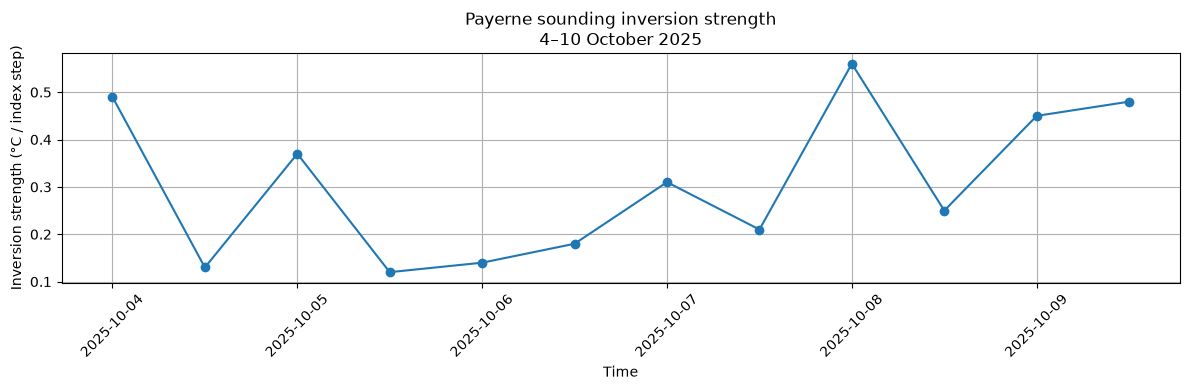

In [8]:
import matplotlib.pyplot as plt

# select period
start = pd.Timestamp("2025-10-04")
end = pd.Timestamp("2025-10-10")

plot_data = results[
    (results["termin"] >= start) &
    (results["termin"] < end)
].copy()

# sort by time
plot_data = plot_data.sort_values("termin")


plt.figure(figsize=(12,4))

plt.plot(
    plot_data["termin"],
    plot_data["inversion_strength"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Inversion strength (°C / index step)")
plt.title("Payerne sounding inversion strength\n4–10 October 2025")

plt.grid()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

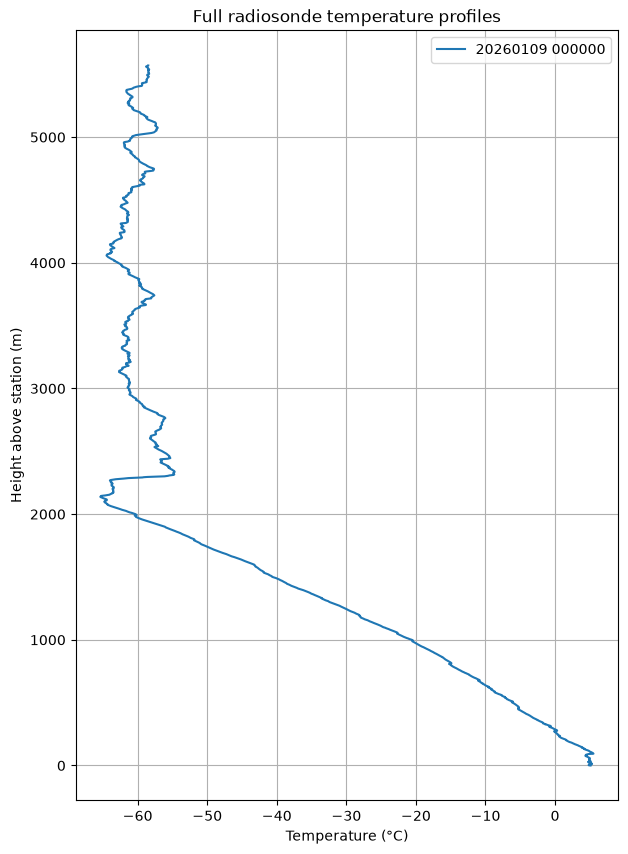

In [9]:
import matplotlib.pyplot as plt

cases=[("20260109_06610_data.txt","20260109000000")]

plt.figure(figsize=(7,10))

for file_name,termin in cases:
    df=read_sounding(soundings_dir/file_name)
    sounding=df[df["termin"]==int(termin)]
    profile=sounding[["level","745"]].dropna().groupby("level",as_index=False)["745"].mean().sort_values("level")
    plt.plot(profile["745"],profile["level"],label=f"{file_name[:8]} {termin[8:]}")

plt.xlabel("Temperature (°C)")
plt.ylabel("Height above station (m)")
plt.title("Full radiosonde temperature profiles")
plt.grid()
plt.legend()
plt.show()